# Scale Invariance

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D



# Function to extract tables from the DataFrame
def extract_tables(df):
    tables = {}
    current_table = None
    i = 0
    
    while i < len(df):
        row = df.iloc[i]
        
        # Check if this is a table title row
        if pd.notna(row[0]) and pd.isna(row[1]) and pd.isna(row[2]):
            current_table = row[0]
            tables[current_table] = []
            i += 1  # Move to the next row (header)
            
            # Get the header
            header = df.iloc[i]
            i += 1  # Move to the first data row
            
            # Collect data rows until we hit an empty row or the end
            while i < len(df) and not (pd.isna(df.iloc[i][0]) and pd.isna(df.iloc[i][1])):
                model_row = df.iloc[i]
                if pd.notna(model_row[0]):  # Only include non-empty rows
                    # Create a dict with model name and values
                    model_data = {
                        'model': model_row[0],
                        '12.5%': float(model_row[1]) if pd.notna(model_row[1]) and model_row[1] != '0' else 0,
                        '25%': float(model_row[2]) if pd.notna(model_row[2]) and model_row[2] != '0' else 0,
                        '50%': float(model_row[3]) if pd.notna(model_row[3]) and model_row[3] != '0' else 0,
                        '100%': float(model_row[4]) if pd.notna(model_row[4]) and model_row[4] != '0' else 0
                    }
                    tables[current_table].append(model_data)
                i += 1
        else:
            i += 1
            
    return tables



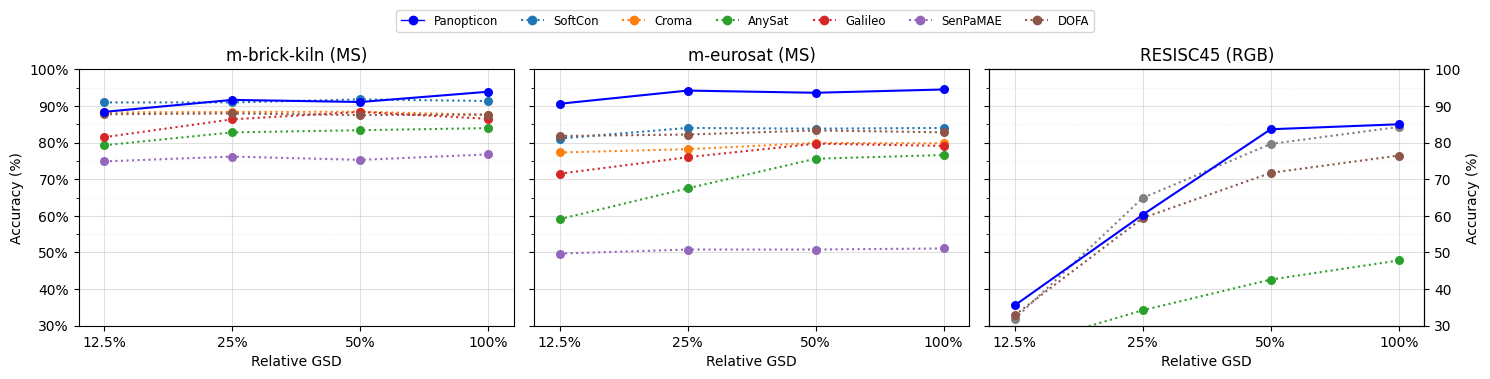

In [24]:
# Read the CSV file
df = pd.read_csv('scale-results.csv', header=None)
# Extract tables
tables = extract_tables(df)
start_y = 30


# Set up the figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
plt.subplots_adjust(top=0.80)  # More room for legend at the top

# Define x-axis values
x_values = ['12.5%', '25%', '50%', '100%']
x_numeric = np.arange(len(x_values))

# Define pastel colors for the models (excluding Panopticon)
pastel_colors = list(mcolors.TABLEAU_COLORS.values())  # Use Tableau colors as they're more vibrant pastels

# Define the order of the tables
table_order = ['Brick Kiln', 'EuroSAT', 'Resisc']

# Create a dictionary to store the color mapping for each model
model_colors = {}
model_list = []

# Get a unique list of models from all tables
for table_name in table_order:
    if table_name in tables:
        for row in tables[table_name]:
            if row['model'] != 'Panopticon' and row['model'] not in model_list and row['model'] != 'DINOv2':
                model_list.append(row['model'])

# Assign colors to models
for i, model in enumerate(model_list):
    model_colors[model] = pastel_colors[i % len(pastel_colors)]

    #change table_order for naming
table_names = ['m-brick-kiln (MS)', 'm-eurosat (MS)', 'RESISC45 (RGB)']

# Plot each table
for i, table_name in enumerate(table_order):
    ax = axes[i]
    
    if table_name in tables:
        # Set the title
        ax.set_title(table_names[i])
        
        # Set x-axis
        ax.set_xticks(x_numeric)
        ax.set_xticklabels(x_values)
        ax.set_xlim(-0.2, len(x_values) - 0.8)
        ax.set_xlabel('Relative GSD')
        
        
        
        # Only show y-axis label on the first subplot
        if i == 0:
            ax.set_ylabel('Accuracy (%)')
            # Set specific y-axis ticks and labels
            y_ticks = np.arange(start_y, 101, 10)  # Major ticks every 10%
            ax.set_yticks(y_ticks)
            ax.set_yticklabels([f'{y:.0f}%' for y in y_ticks])  # Add % sign to labels
            ax.set_yticks(np.arange(50, 101, 5), minor=True)  # Minor ticks every 5%
        else:
            ax.tick_params(axis='y', which='both', labelleft=False)  # Remove y-axis labels for other subplots
        if i == 2:
            ax2 = ax.twinx()
            ax2.set_ylim(start_y, 100)  # Match the primary y-axis range
            ax2.set_ylabel('Accuracy (%)')
            
        ax.set_ylim(start_y, 100)  # Set y-axis range from 50% to 100%

        # # Remove border but keep axis lines
        # for spine in ['top', 'right']:
        #     ax.spines[spine].set_visible(False)
        
        # Add light grid with minor horizontal lines
        ax.grid(visible=True, which='major', color='lightgray', linestyle='-', alpha=0.7)
        ax.grid(visible=True, which='minor', color='lightgray', linestyle=':', alpha=0.4, axis='y')
        
        # Plot each model in the table
        for row in tables[table_name]:
            model = row['model']
            if model != 'dinov2':  # Skip dinov2 as it has all zeros
                y_values = [row['12.5%'], row['25%'], row['50%'], row['100%']]
                
                if model.lower() == 'panopticon':
                    # Panopticon gets a solid blue line with dots
                    ax.plot(x_numeric, y_values, '-', color='blue', linewidth=1.5, label='Panopticon')
                    ax.scatter(x_numeric, y_values, color='blue', s=30, zorder=10)
                else:
                    # Other models get dotted lines with pastel colors and dots
                    color = model_colors.get(model, 'gray')
                    ax.plot(x_numeric, y_values, ':', color=color, linewidth=1.5, label=model)
                    ax.scatter(x_numeric, y_values, color=color, s=30, zorder=10)
    
# Create a single legend above all subplots
handles = []

# Add Panopticon to legend first
handles.append(Line2D([0], [0], color='blue', linewidth=1, marker='o', label='Panopticon'))

# Add other models to legend
for model in model_list:
    color = model_colors[model]
    handles.append(Line2D([0], [0], color=color, linestyle=':', marker='o', linewidth=1.5, label=model))

# fig.legend(handles=handles, loc='upper center', ncol=min(4, len(model_list) + 1), 
#            bbox_to_anchor=(0.21, 0.3), fontsize='small')
fig.legend(handles=handles, loc='upper center', ncol=7, 
           bbox_to_anchor=(0.5, 0.95), fontsize='small')
# Adjust layout
# plt.tight_layout()

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.88])
# Save the figure
plt.savefig('scaling_results.png', dpi=300, bbox_inches='tight')

# Show the figure
plt.show()


In [9]:
model_colors

{'SoftCon': '#1f77b4',
 'Croma': '#ff7f0e',
 'AnySat': '#2ca02c',
 'Galileo': '#d62728',
 'SenPaMAE': '#9467bd',
 'DOFA': '#8c564b'}

# Spec Invariance

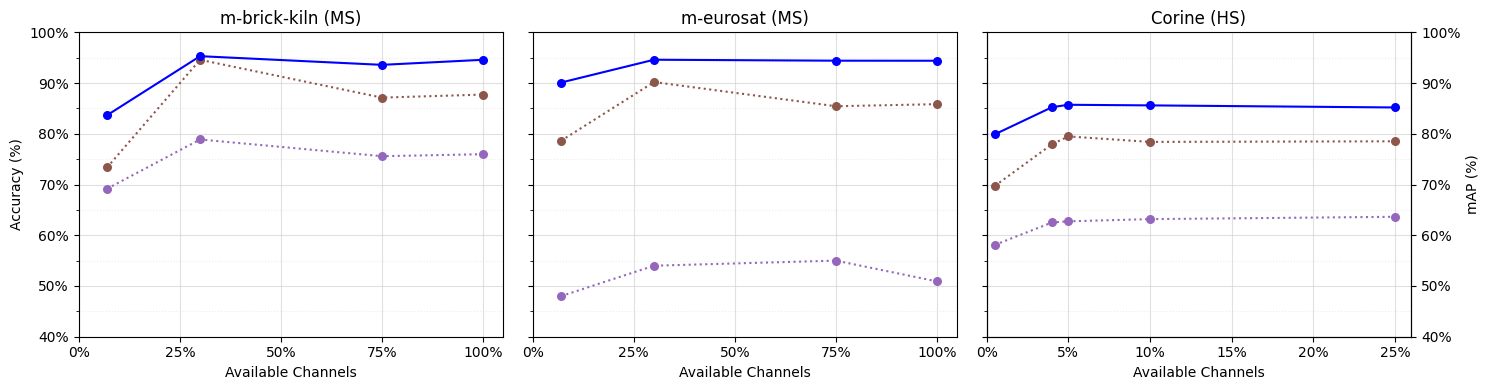

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

start_y = 40

# Define pastel colors for the models (excluding Panopticon)
pastel_colors = list(mcolors.TABLEAU_COLORS.values())  # Use Tableau colors as they're more vibrant pastels

# Define model colors (consistent with previous plots)
model_colors = {
    'Panopticon': 'blue',
    'DOFA': '#8c564b',
    'SenPaMAE': '#9467bd'
}

# Define line styles
model_styles = {
    'Panopticon': '-',
    'DOFA': ':',
    'SenPaMAE': ':'
}

# Manual data from CSV
brick_kiln = {
    'header': ['7.00%', '30.00%', '75.00%', '100.00%'],
    'data': [
        {'model': 'SenPaMAE', 'values': [69.17, 78.88, 75.58, 75.98]},
        {'model': 'DOFA', 'values': [73.37, 94.59, 87.13, 87.73]},
        {'model': 'Panopticon', 'values': [83.66, 95.3, 93.59, 94.59]}
    ]
}

eurosat = {
    'header': ['7.00%', '30.00%', '75.00%', '100.00%'],
    'data': [
        {'model': 'SenPaMAE', 'values': [48, 54, 55, 50.9]},
        {'model': 'DOFA', 'values': [78.62, 90.2, 85.43, 85.84]},
        {'model': 'Panopticon', 'values': [90.1, 94.6, 94.41, 94.4]}
    ]
}

corine = {
    'header': ['0.50%', '4.00%', '5.00%', '10.00%', '25.00%'],
    'data': [
        {'model': 'SenPaMAE', 'values': [58.11, 62.52, 62.75, 63.18, 63.64]},
        {'model': 'DOFA', 'values': [69.73, 77.94, 79.48, 78.4, 78.52]},
        {'model': 'Panopticon', 'values': [79.9, 85.24, 85.72, 85.6, 85.19]}
    ]
}

# Combine all tables
tables = {
    'Brick Kiln': brick_kiln,
    'EuroSAT': eurosat,
    'Corine': corine
}

# Set up the figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
plt.subplots_adjust(top=0.80)  # More room for legend at the top

# Define the order of the tables
table_order = ['Brick Kiln', 'EuroSAT', 'Corine']
table_names = ['m-brick-kiln (MS)', 'm-eurosat (MS)', 'Corine (HS)']

# Plot each table
for i, table_name in enumerate(table_order):
    ax = axes[i]
    table = tables[table_name]
    
    # Set the title
    ax.set_title(table_names[i])
    
    # Convert percentage strings to numeric values for plotting
    x_values = [float(p.strip('%')) for p in table['header']]
    
    # Set up the x-axis limits and grid lines
    if table_name == 'Corine':
        ax.set_xlim(0, 26)  # Extend slightly beyond 25% to avoid cutting off dots
        # Set equally spaced grid lines every 5%
        grid_locations = np.arange(0, 26, 5)  # 0, 5, 10, 15, 20, 25
        ax.set_xticks(grid_locations)
        ax.set_xticklabels([f"{x}%" for x in grid_locations])
    else:
        ax.set_xlim(0, 105)  # Extend slightly beyond 100% to avoid cutting off dots
        # Set equally spaced grid lines every 25%
        grid_locations = np.arange(0, 101, 25)  # 0, 25, 50, 75, 100
        ax.set_xticks(grid_locations)
        ax.set_xticklabels([f"{x}%" for x in grid_locations])
    
    # Remove border but keep axis lines
    # for spine in ['top', 'right']:
    #     ax.spines[spine].set_visible(False)

    ax.set_xlabel('Available Channels')
    
    # Handle y-axis labels based on subplot position
    if i == 0:
        # First subplot: Left y-axis labeled 'Accuracy (%)'
        ax.set_ylabel('Accuracy (%)')
        # Set specific y-axis ticks and labels
        y_ticks = np.arange(start_y, 101, 10)  # Major ticks every 10%
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([f'{y:.0f}%' for y in y_ticks])  # Add % sign to labels
        ax.set_yticks(np.arange(start_y, 101, 5), minor=True)  # Minor ticks every 5%
    elif i == 2:
        # Third subplot: Add second y-axis on the right for mAP
        ax.tick_params(axis='y', which='both', labelleft=False)  # Remove left y-axis labels
        
        # Create a second y-axis that shares the same range
        ax2 = ax.twinx()
        ax2.set_ylim(start_y, 100)  # Match the primary y-axis range
        ax2.set_ylabel('mAP (%)')
        y_ticks = np.arange(start_y, 101, 10)
        ax2.set_yticks(y_ticks)
        ax2.set_yticklabels([f'{y:.0f}%' for y in y_ticks])
        
        # Keep the right spine but remove the top one
        ax2.spines['top'].set_visible(False)
    else:
        # Middle subplot: No y-axis labels
        ax.tick_params(axis='y', which='both', labelleft=False)  # Remove y-axis labels
        
    ax.set_ylim(start_y, 100)  # Set y-axis range from 50% to 100%
    
    # Add grid lines
    ax.grid(visible=True, which='major', color='lightgray', linestyle='-', alpha=0.7)
    ax.grid(visible=True, which='minor', color='lightgray', linestyle=':', alpha=0.4, axis='y')
    
    # Plot each model in the table
    for row in table['data']:
        model = row['model']
        y_values = row['values']
        
        color = model_colors.get(model, 'gray')
        linestyle = model_styles.get(model, '-')
        
        # Plot the data points with actual x values
        ax.plot(x_values, y_values, linestyle, color=color, 
                linewidth=1.5 if model == 'Panopticon' else 1.5, label=model)
        ax.scatter(x_values, y_values, color=color, s=30, zorder=10)

# Create a single legend above all subplots
handles = []

# Add models to legend in a specific order
for model in ['Panopticon', 'DOFA', 'SenPaMAE']:
    color = model_colors.get(model, 'gray')
    linestyle = model_styles.get(model, '-')
    linewidth = 2 if model == 'Panopticon' else 1.5
    handles.append(Line2D([0], [0], color=color, linestyle=linestyle, marker='o', 
                          linewidth=linewidth, label=model))

# fig.legend(handles=handles, loc='upper center', ncol=3, 
#            bbox_to_anchor=(0.5, 0.95), fontsize='small')

# Adjust layout
# plt.tight_layout(rect=[0, 0, 1, 0.9])  # Make room for the legend at the top
plt.tight_layout()

# Save the figure
plt.savefig('spectral_results.png', dpi=300, bbox_inches='tight')

# Show the figure
plt.show()